In [ ]:
#OBSERVER
class Subscriber:
    def __init__(self, name):
        self.name = name
        self.channel = None

    def update(self):
        if self.channel:
            print(f"Hey {self.name}, Video Uploaded: {self.channel.title}")

    def subscribe_channel(self, channel):
        self.channel = channel
        channel.subscribe(self)

    def unsubscribe_channel(self, channel):
        if self.channel == channel:
            self.channel = None
            channel.unsubscribe(self)


class Channel:
    def __init__(self):
        self.subscribers = []

    def subscribe(self, subscriber):
        self.subscribers.append(subscriber)

    def unsubscribe(self, subscriber):
        self.subscribers.remove(subscriber)

    def notify_subscribers(self):
        for subscriber in self.subscribers:
            subscriber.update()

    def upload(self, title):
        self.title = title
        self.notify_subscribers()


if __name__ == "__main__":
    taufiq_channel = Channel()

    s1 = Subscriber("opu")
    s2 = Subscriber("topu")
    s3 = Subscriber("rakib")
    s4 = Subscriber("shanto")
    s5 = Subscriber("nasim")


    s1.subscribe_channel(taufiq_channel)
    s2.subscribe_channel(taufiq_channel)
    s3.subscribe_channel(taufiq_channel)
    s4.subscribe_channel(taufiq_channel)
    s5.subscribe_channel(taufiq_channel)

    taufiq_channel.unsubscribe(s2)

    taufiq_channel.upload("CSE 470 class")

    aumio_channel = Channel()

    s1.subscribe_channel(aumio_channel)
    aumio_channel.subscribe(s1)
    print(taufiq_channel is aumio_channel)

    aumio_channel.upload("New Video")
    taufiq_channel.upload("CSE 470 class")


Hey opu, Video Uploaded: CSE 470 class
Hey rakib, Video Uploaded: CSE 470 class
Hey shanto, Video Uploaded: CSE 470 class
Hey nasim, Video Uploaded: CSE 470 class
False
Hey opu, Video Uploaded: New Video
Hey opu, Video Uploaded: New Video
Hey opu, Video Uploaded: New Video
Hey rakib, Video Uploaded: CSE 470 class
Hey shanto, Video Uploaded: CSE 470 class
Hey nasim, Video Uploaded: CSE 470 class


In [ ]:
#
class Channel:
  def __init__(self):
    self._subscribers = []

  def upload(self, video_title):
    print(f"A new video is uploaded. The title is {video_title}")
    self._notify_subscribers(video_title)

  def _notify_subscribers(self, video_title):
    for subscriber in self._subscribers:
      subscriber.update(video_title)

  def attach(self, subscriber):
    self._subscribers.append(subscriber)

  def detach(self, subscriber):
    self._subscribers.remove(subscriber)



class Subscriber:
  def __init__(self, name):
    self.channels = []
    self.name = name

  def subscribe(self, channel):
    self.channels.append(channel)
    channel.attach(self)

  def unsubscribe(self, channel):
    print(f'{self.name} has unsubscribed from this {channel}')
    self.channels.remove(channel)
    channel.detach(self)

  def update(self, video_title):
    print(f"{self.name}  {video_title}")

Twitter = Channel()
My_channel = Channel()
sub_1 = Subscriber("sub1")
sub_2 = Subscriber("sub2")

s1.subscribe(Twitter)
s2.subscribe(My_channel)

Twitter.upload("video1")
My_channel.upload("video2")

s2.unsubscribe(My_channel)
Twitter.upload("video3")
My_channel.upload("video4")

print(Twitter is My_channel)

AttributeError: 'Subscriber' object has no attribute 'subscribe'

In [ ]:
# Subject (Celebrity)
class Celebrity:
    def __init__(self):
        self._fans = []
        self._state = None
    def attach(self, fan):
        self._fans.append(fan)
    def detach(self, fan):
        self._fans.remove(fan)
    def _notify(self):
        for fan in self._fans:
            fan.update(self)
            print(f"{fan} notified")
    def set_state(self, state):
        self._state = state
        self._notify()
    def get_state(self):
        return self._state
# Observer (Fan)
class Fan:
    def __init__(self,name):
        self._celebrities = []
        self.name = name
    def update(self, celebrity):
        state = celebrity.get_state()
    def add_celebrity(self, celebrity):
        self._celebrities.append(celebrity)
        celebrity.attach(self)
    def remove_celebrity(self, celebrity):
        self._celebrities.remove(celebrity)
        celebrity.detach(self)
celebrity = Celebrity()
fan = Fan('aumio')
#fan starts following…
fan.add_celebrity(celebrity)
#celeb changes status and #notification is received by fan.
celebrity.set_state('New state')
celebrity._notify()
#fan can stop following…
fan.remove_celebrity(celebrity)


In [ ]:
class HelpDesk:
    _instance = None
    def __new__(cls):
        if cls._instance is None:
            print('Creating the HelpDesk instance')
            cls._instance = super(HelpDesk,cls).__new__(cls)
        return cls._instance

    def get_service(self):
        print("Service provided by the HelpDesk.")


# Usage
if __name__ == "__main__":
    student_help_desk = HelpDesk()
    teacher_help_desk = HelpDesk()


    student_help_desk.get_service()
    teacher_help_desk.get_service()

    print(student_help_desk is teacher_help_desk)


In [ ]:
class Channel:
    _instance = None

    def __new__(cls):
        if cls._instance is None:
            cls._instance = super(Channel, cls).__new__(cls)
            cls.name = "Twitter"
            cls.subscribers = []
        return cls._instance

    def subscribe(self, user):
        self.subscribers.append(user)

    def notify_subscribers(self, video_title):
        for user in self.subscribers:
            user.update(video_title)

class User:
    def __init__(self, name):
        self.name = name

    def update(self, video_title):
        print(f"{self.name}, new video released: {video_title}")

twitter_channel = Channel()
new_channel = Channel()
print(twitter_channel is new_channel)

user1 = User("Aumio")
user2 = User("Arnab")

twitter_channel.subscribe(user1)
twitter_channel.subscribe(user2)

twitter_channel.notify_subscribers("New Video on Twitter!")
new_channel.notify_subscribers("New Video on Twitter!")


True
Aumio, new video released: New Video on Twitter!
Arnab, new video released: New Video on Twitter!
Aumio, new video released: New Video on Twitter!
Arnab, new video released: New Video on Twitter!


In [ ]:
class Channel():
  def __init__(self):
    self.__subscribers = []
    self.title = None

  def upload(self, video_title):
    self.title = video_title
    print(f"A new video is uploaded. The title is {video_title}")
    self.__notify_subscribers()

  def __notify_subscribers(self):
    for subscriber in self.__subscribers:
      subscriber.update(self)

  def attach(self, subscriber):
    self.__subscribers.append(subscriber)

  def detach(self, subscriber):
    self.__subscribers.remove(subscriber)

class Subscriber():
  def __init__(self, name):
    self._channels = []
    self._name = name

  def subscribe(self, channel):
    self._channels.append(channel)
    channel.attach(self)

  def unsubscribe(self, channel):
    self._channels.remove(channel)
    channel.detach(self)

  def update(self,channel):
    if channel in self._channels:
      print(f"{self._name} has received {channel.title}")


if __name__ == "__main__":
    taufiq_channel = Channel()

    s1 = Subscriber("opu")
    s2 = Subscriber("topu")
    s3 = Subscriber("rakib")
    s4 = Subscriber("shanto")
    s5 = Subscriber("nasim")

    s1.subscribe(taufiq_channel)
    s2.subscribe(taufiq_channel)
    s3.subscribe(taufiq_channel)
    s4.subscribe(taufiq_channel)
    s5.subscribe(taufiq_channel)

    s2.unsubscribe(taufiq_channel)

    taufiq_channel.upload("CSE 470 class")

    aumio_channel = Channel()

    s1.subscribe(aumio_channel)

    aumio_channel.upload("New Video")
    taufiq_channel.upload("CSE 470 class")

A new video is uploaded. The title is CSE 470 class
opu has received CSE 470 class
rakib has received CSE 470 class
shanto has received CSE 470 class
nasim has received CSE 470 class
A new video is uploaded. The title is New Video
opu has received New Video
A new video is uploaded. The title is CSE 470 class
opu has received CSE 470 class
rakib has received CSE 470 class
shanto has received CSE 470 class
nasim has received CSE 470 class


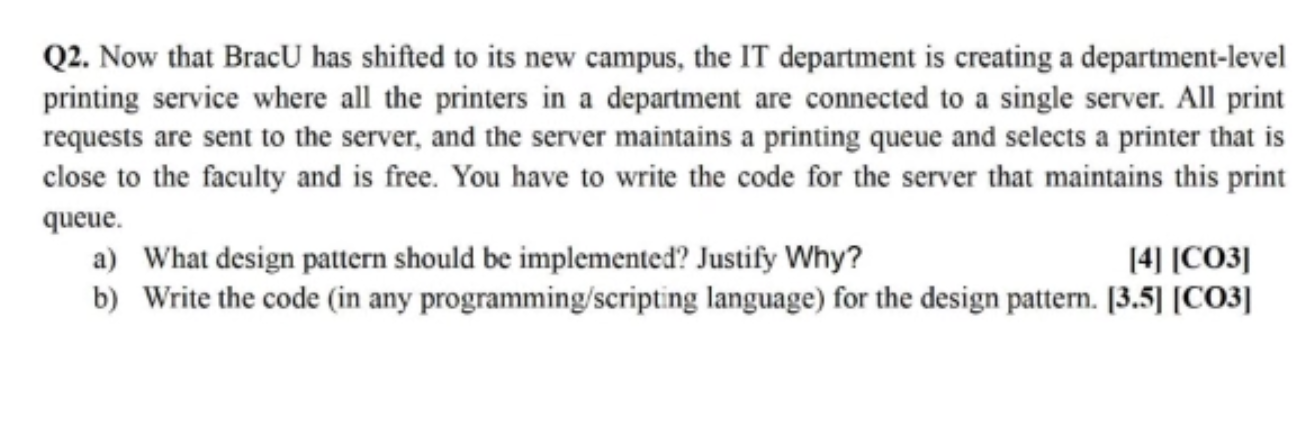

In [ ]:
class Server:
    __instance = None
    def __new__(cls):
      if cls.__instance is None:
          cls.__instance = super(Server, cls).__new__(cls)
      return cls.__instance


    def __init__(self):
      self.printing_queue = []


    def add_to_queue(self, printer):
      self.printing_queue.append(printer)




    def printerPrint(self):
      for printer in self.printing_queue:
        if printer.isFree == True:
          printer.update()




class Printer:
    def __init__(self, number, server):
      self.number = number
      self.isFree = True
      self.server = server

    def printRequest(self):
       self.server.add_to_queue(self)

    def update(self):
      print(f"{self.number} is printing")
      self.isFree = False

S = Server()

p1 = Printer(1, S)
p2 = Printer(2, S)
p3 = Printer(3,S)

p1.printRequest()
p2.printRequest()
p3.printRequest()

S.printerPrint()





1 is printing
2 is printing
3 is printing
